## Problem 1 - Build Convolution Neural Network with Lenet Model

In [1]:
import tensorflow as tf

In [2]:
output_size = 10
img_size= 28
lenet_model = tf.keras.models.Sequential(
            tf.keras.layers.Conv2D(), # C1 your code here
            tf.keras.layers.AvgPool2D(), # S2 your code here
            tf.keras.layers.Conv2D(), # C3 your code here
            tf.keras.layers.AvgPool2D(), # S4 your code here
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(), # C5 your code here
            tf.keras.layers.Dense(), # F6 your code here
            tf.keras.layers.Dense()) # Output layer, your code here

lenet_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 6)         456       
                                                                 
 average_pooling2d (AverageP  (None, 14, 14, 6)        0         
 ooling2D)                                                       
                                                                 
 conv2d_1 (Conv2D)           (None, 10, 10, 16)        2416      
                                                                 
 average_pooling2d_1 (Averag  (None, 5, 5, 16)         0         
 ePooling2D)                                                     
                                                                 
 flatten (Flatten)           (None, 400)               0         
                                                                 
 dense (Dense)               (None, 120)               4

## Problem 2 - Build Networks Using Blocks (VGG16)

In [3]:
output_size = 1000
img_size = 224

vgg16_model = tf.keras.models.Sequential(
                # 1st Conv Block
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.MaxPool2D(), #your code here

                # 2nd Conv Block
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.MaxPool2D(), #your code here

                # 3rd Conv block
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.MaxPool2D(), #your code here

                # 4th Conv block
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.MaxPool2D(), #your code here

                # 5th Conv block
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.MaxPool2D(), #your code here

                # Fully connected layers
                tf.keras.layers.Flatten(),
                tf.keras.layers.Dense(), #your code here
                tf.keras.layers.Dense(), #your code here
                tf.keras.layers.Dense() #your code here

vgg16_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 224, 224, 64)      1792      
                                                                 
 conv2d_3 (Conv2D)           (None, 224, 224, 64)      36928     
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 64)     0         
 )                                                               
                                                                 
 conv2d_4 (Conv2D)           (None, 112, 112, 128)     73856     
                                                                 
 conv2d_5 (Conv2D)           (None, 112, 112, 128)     147584    
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 56, 56, 128)      0         
 2D)                                                  

## Problem 3 - Image classification using Lenet and VGG16

### 3.1 - Concrete crack dataset

#### Load data

In [26]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from imutils import paths
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from keras.preprocessing.image import ImageDataGenerator
from keras.models import load_model

In [ ]:
path = "/content/save_model"
os.mkdir(path)

In [5]:
!pip install GitPython
from git import Repo

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 182 kB 31.6 MB/s 
     |████████████████████████████████| 62 kB 1.4 MB/s 


In [6]:
filepath = 'temp_concrete_crack'
Repo.clone_from('https://github.com/bimewok/Concrete-Crack-Image-Classifier', filepath)

<git.repo.base.Repo '/content/temp_concrete_crack/.git'>

In [ ]:
base_dir = '/content/temp_concrete_crack/data/concrete_images'
train_dir = os.path.join(base_dir, 'train')
valid_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')



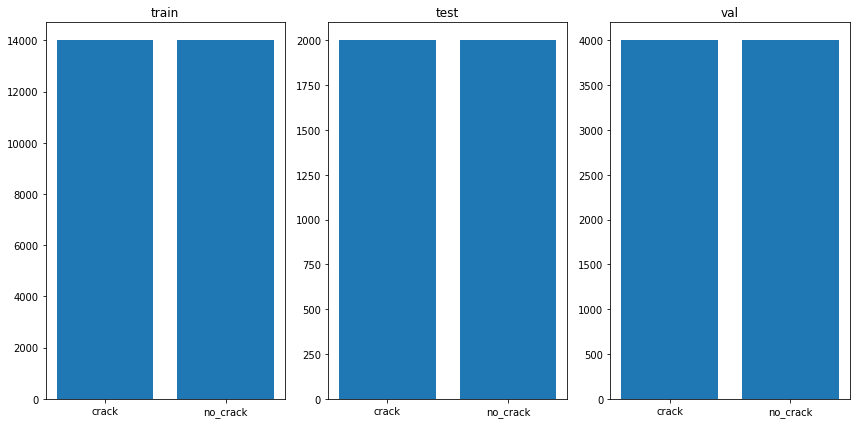

In [9]:
def show_labels(data_dir):
    data = os.listdir(data_dir)
    fig, ax = plt.subplots(1, len(data), figsize=(12,6))
    for idx in range(len(data)):
        sub_dir = os.path.join(data_dir, data[idx])
        labels = os.listdir(sub_dir)
        list_data = []
        for label in labels:
            image_files = list(paths.list_images(os.path.join(sub_dir, label)))
            list_data.append(len(image_files))
        ax[idx].bar(labels, list_data)
        ax[idx].set_title(data[idx])
        # ax[idx].axis('off')
    plt.tight_layout()
    plt.show()
    
show_labels(base_dir)

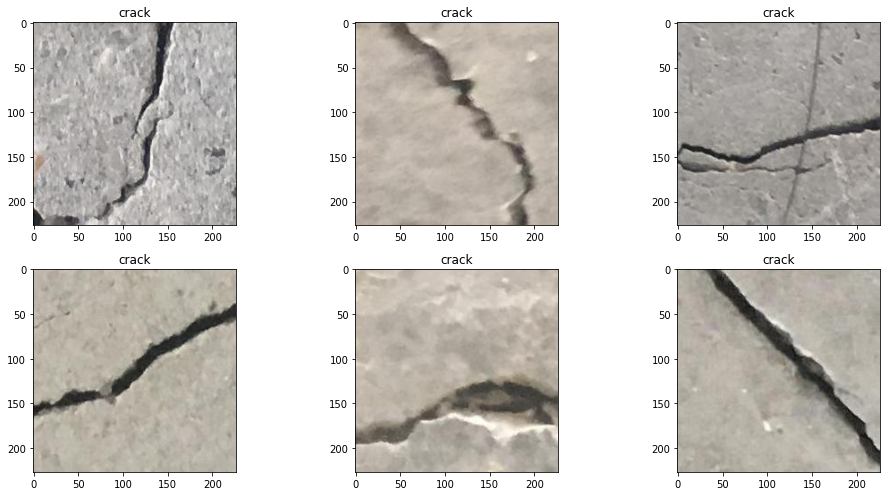

In [10]:
def plot_images(data_dir, label, num_sample=6):
    data_dir = os.path.join(data_dir, label)
    image_files = list(paths.list_images(data_dir))[:num_sample]
    fig, ax = plt.subplots(2,num_sample//2, figsize=(14,7))
    for i, image_dir in enumerate(image_files):
        img = mpimg.imread(image_dir)
        ax[i//(num_sample//2)][i%(num_sample//2)].imshow(img)
        ax[i//(num_sample//2)][i%(num_sample//2)].set_title(label)
    plt.tight_layout()
    plt.show()
  
plot_images(train_dir, label="crack")

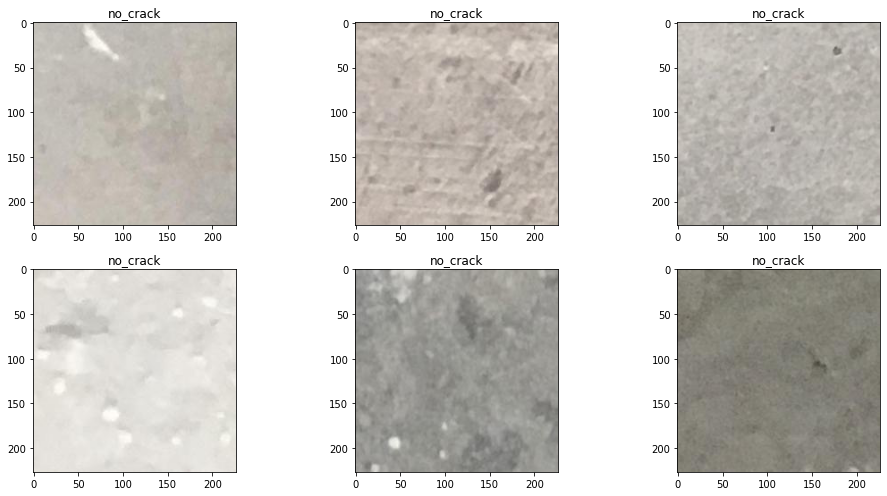

In [11]:
plot_images(train_dir, label="no_crack")

#### Preprocessing

In [12]:
img_size = 150 # img.shape[0] = 227
output_size = 1 #Use sigmoid function
batch_size = 256

train_datagen = ImageDataGenerator( rescale=1.0/255.0,
                                    rotation_range=30,
                                    zoom_range=0.15,
                                    width_shift_range=0.2,
                                    height_shift_range=0.2,
                                    shear_range=0.15,
                                    horizontal_flip=True,
                                    fill_mode="nearest" )

val_datagen = ImageDataGenerator(rescale=1.0/255.0)

test_datagen = ImageDataGenerator(rescale=1.0/255.0)

# prepare iterators
train_dataloader = train_datagen.flow_from_directory(train_dir, 
                                                     class_mode='binary', 
                                                     batch_size=batch_size, 
                                                     target_size=(img_size, img_size))

valid_dataloader = val_datagen.flow_from_directory(valid_dir, 
                                         class_mode='binary', 
                                         batch_size=batch_size, 
                                         target_size=(img_size, img_size))

test_dataloader = test_datagen.flow_from_directory(test_dir, 
                                           class_mode='binary', 
                                           batch_size=batch_size, 
                                           target_size=(img_size, img_size))

Found 28000 images belonging to 2 classes.
Found 8000 images belonging to 2 classes.
Found 4000 images belonging to 2 classes.


#### Model LeNet

In [13]:

lenet_model = tf.keras.models.Sequential(
            tf.keras.layers.Conv2D(), # C1 #your code here
            tf.keras.layers.AvgPool2D(), # S2 #your code here
            tf.keras.layers.Conv2D(), # C3 #your code here
            tf.keras.layers.AvgPool2D(), # S4 #your code here
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(), # C5 #your code here
            tf.keras.layers.Dense(), # F6 #your code here
            tf.keras.layers.Dense()) # Output layer #your code here

lenet_model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_15 (Conv2D)          (None, 150, 150, 6)       456       
                                                                 
 average_pooling2d_2 (Averag  (None, 75, 75, 6)        0         
 ePooling2D)                                                     
                                                                 
 conv2d_16 (Conv2D)          (None, 71, 71, 16)        2416      
                                                                 
 average_pooling2d_3 (Averag  (None, 35, 35, 16)       0         
 ePooling2D)                                                     
                                                                 
 flatten_2 (Flatten)         (None, 19600)             0         
                                                                 
 dense_6 (Dense)             (None, 120)              

In [15]:
lenet_model.compile(optimizer='adam',loss="binary_crossentropy", metrics=['accuracy'])
lenet_model.summary()

num_epochs = 10

checkpoint_path = "/content/save_model/lenet_concrete_crack.h5"

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
            filepath=checkpoint_path,
            verbose=1,
            save_weights_only=True,
            monitor='val_accuracy',
            mode='max',
            save_best_only=True)
learning_rate_reduction = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', 
                                            patience = 2, 
                                            verbose=1,
                                            factor=0.5, 
                                            min_lr=0.00001)

history = lenet_model.fit(train_dataloader,
                        epochs = num_epochs,
                        validation_data = valid_dataloader,
                        callbacks=[model_checkpoint, learning_rate_reduction])

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_15 (Conv2D)          (None, 150, 150, 6)       456       
                                                                 
 average_pooling2d_2 (Averag  (None, 75, 75, 6)        0         
 ePooling2D)                                                     
                                                                 
 conv2d_16 (Conv2D)          (None, 71, 71, 16)        2416      
                                                                 
 average_pooling2d_3 (Averag  (None, 35, 35, 16)       0         
 ePooling2D)                                                     
                                                                 
 flatten_2 (Flatten)         (None, 19600)             0         
                                                                 
 dense_6 (Dense)             (None, 120)              

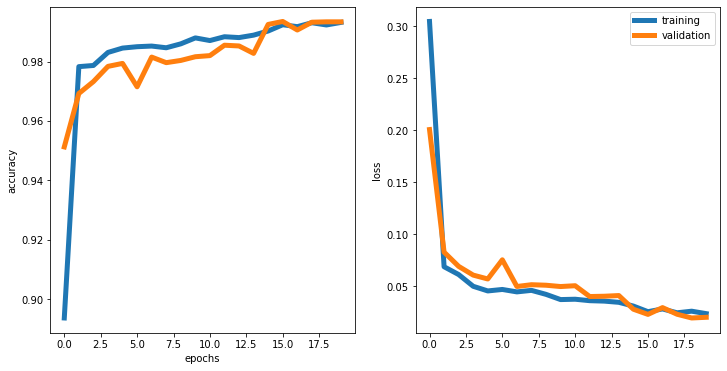

In [16]:
fig, axs = plt.subplots(nrows = 1, ncols =2 , figsize = (12,6))
axs[0].plot(range(len(lenet_model.history.history['accuracy'])), lenet_model.history.history['accuracy'], linewidth = 5, label = "training")
axs[0].plot(range(len(lenet_model.history.history['accuracy'])), lenet_model.history.history['val_accuracy'], linewidth = 5, label = "validation")
axs[1].plot(range(len(lenet_model.history.history['loss'])), lenet_model.history.history['loss'], linewidth = 5, label = "training")
axs[1].plot(range(len(lenet_model.history.history['loss'])), lenet_model.history.history['val_loss'], linewidth = 5, label = "validation")
axs[0].set_xlabel("epochs")
axs[0].set_xlabel("epochs")
axs[0].set_ylabel("accuracy")
axs[1].set_ylabel("loss")
plt.legend()

In [17]:
lenet_model.load_weights("/content/save_model/lenet_concrete_crack.h5")
loss, accuracy = lenet_model.evaluate(test_dataloader, steps=len(test_dataloader), verbose=1)

16/16 [==============================] - 6s 350ms/step - loss: 0.0203 - accuracy: 0.9940


#### Model VGG-16

In [18]:
vgg16_model = tf.keras.models.Sequential(
                # 1st Conv Block
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.MaxPool2D(), #your code here

                # 2nd Conv Block
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.MaxPool2D(), #your code here

                # 3rd Conv block
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.MaxPool2D(), #your code here

                # 4th Conv block
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.MaxPool2D(), #your code here

                # 5th Conv block
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.MaxPool2D(), #your code here

                # Fully connected layers
                tf.keras.layers.Flatten(),
                tf.keras.layers.Dense(), #your code here
                tf.keras.layers.Dense(), #your code here
                tf.keras.layers.Dense() #your code here

vgg16_model.compile(optimizer='adam',loss="binary_crossentropy", metrics=['accuracy'])
vgg16_model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_17 (Conv2D)          (None, 150, 150, 64)      1792      
                                                                 
 conv2d_18 (Conv2D)          (None, 150, 150, 64)      36928     
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 75, 75, 64)       0         
 2D)                                                             
                                                                 
 conv2d_19 (Conv2D)          (None, 75, 75, 128)       73856     
                                                                 
 conv2d_20 (Conv2D)          (None, 75, 75, 128)       147584    
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 38, 38, 128)      0         
 2D)                                                  

In [19]:
num_epochs = 10

checkpoint_path = "/content/save_model/base_vgg16_concrete_crack.h5"

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
            filepath=checkpoint_path,
            verbose=1,
            save_weights_only=True,
            monitor='val_accuracy',
            mode='max',
            save_best_only=True)
learning_rate_reduction = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', 
                                            patience = 2, 
                                            verbose=1,
                                            factor=0.5, 
                                            min_lr=0.00001)

history = vgg16_model.fit(train_dataloader,
                                epochs = num_epochs,
                                validation_data = valid_dataloader,
                                callbacks=[model_checkpoint, learning_rate_reduction])

Epoch 1/20
110/110 [==============================] - ETA: 0s - loss: 0.6963 - accuracy: 0.5019
Epoch 1: val_accuracy improved from -inf to 0.50000, saving model to /content/save_model/base_vgg16_concrete_crack.h5
110/110 [==============================] - 263s 2s/step - loss: 0.6963 - accuracy: 0.5019 - val_loss: 0.6933 - val_accuracy: 0.5000 - lr: 0.0010
Epoch 2/20
110/110 [==============================] - ETA: 0s - loss: 0.6933 - accuracy: 0.5004
Epoch 2: val_accuracy did not improve from 0.50000
110/110 [==============================] - 231s 2s/step - loss: 0.6933 - accuracy: 0.5004 - val_loss: 0.6932 - val_accuracy: 0.5000 - lr: 0.0010
Epoch 3/20
110/110 [==============================] - ETA: 0s - loss: 0.6932 - accuracy: 0.5000
Epoch 3: val_accuracy did not improve from 0.50000

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
110/110 [==============================] - 232s 2s/step - loss: 0.6932 - accuracy: 0.5000 - val_loss: 0.6931 - val_accuracy: 

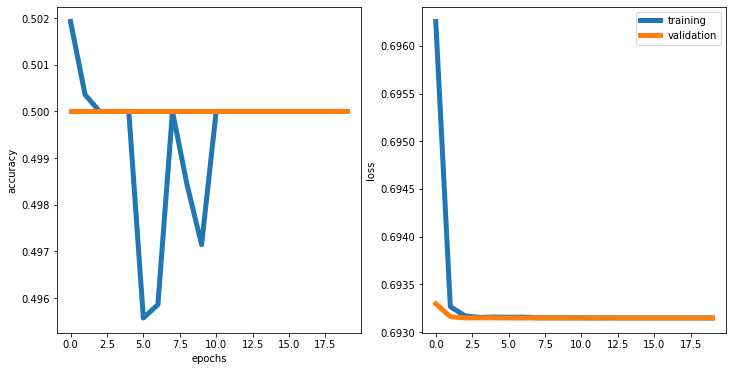

In [20]:
fig, axs = plt.subplots(nrows = 1, ncols =2 , figsize = (12,6))
axs[0].plot(range(len(vgg16_model.history.history['accuracy'])), vgg16_model.history.history['accuracy'], linewidth = 5, label = "training")
axs[0].plot(range(len(vgg16_model.history.history['accuracy'])), vgg16_model.history.history['val_accuracy'], linewidth = 5, label = "validation")
axs[1].plot(range(len(vgg16_model.history.history['loss'])), vgg16_model.history.history['loss'], linewidth = 5, label = "training")
axs[1].plot(range(len(vgg16_model.history.history['loss'])), vgg16_model.history.history['val_loss'], linewidth = 5, label = "validation")
axs[0].set_xlabel("epochs")
axs[0].set_xlabel("epochs")
axs[0].set_ylabel("accuracy")
axs[1].set_ylabel("loss")
plt.legend()

In [21]:
vgg16_model.load_weights("/content/save_model/base_vgg16_concrete_crack.h5")
loss, accuracy = vgg16_model.evaluate(test_dataloader, verbose=1)

16/16 [==============================] - 16s 1s/step - loss: 0.6933 - accuracy: 0.5000


#### Improve VGG-16: dùng he_uniform

In [22]:
vgg16_model = tf.keras.models.Sequential(
                # 1st Conv Block
                tf.keras.layers.Conv2D(, kernel_initializer='he_uniform'), #your code here
                tf.keras.layers.Conv2D(, kernel_initializer='he_uniform'), #your code here
                tf.keras.layers.MaxPool2D(), #your code here

                # 2nd Conv Block
                tf.keras.layers.Conv2D(, kernel_initializer='he_uniform'), #your code here
                tf.keras.layers.Conv2D(, kernel_initializer='he_uniform'), #your code here
                tf.keras.layers.MaxPool2D(), #your code here

                # 3rd Conv block
                tf.keras.layers.Conv2D(, kernel_initializer='he_uniform'), #your code here
                tf.keras.layers.Conv2D(, kernel_initializer='he_uniform'), #your code here
                tf.keras.layers.Conv2D(, kernel_initializer='he_uniform'), #your code here
                tf.keras.layers.MaxPool2D(), #your code here

                # 4th Conv block
                tf.keras.layers.Conv2D(, kernel_initializer='he_uniform'), #your code here
                tf.keras.layers.Conv2D(, kernel_initializer='he_uniform'), #your code here
                tf.keras.layers.Conv2D(, kernel_initializer='he_uniform'), #your code here
                tf.keras.layers.MaxPool2D(), #your code here

                # 5th Conv block
                tf.keras.layers.Conv2D(, kernel_initializer='he_uniform'), #your code here
                tf.keras.layers.Conv2D(, kernel_initializer='he_uniform'), #your code here
                tf.keras.layers.Conv2D(, kernel_initializer='he_uniform'), #your code here
                tf.keras.layers.MaxPool2D(), #your code here

                # Fully connected layers
                tf.keras.layers.Flatten(),
                tf.keras.layers.Dense(), #your code here
                tf.keras.layers.Dense(), #your code here
                tf.keras.layers.Dense() #your code here

vgg16_model.compile(optimizer='sgd',loss="binary_crossentropy", metrics=['accuracy'])
vgg16_model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_30 (Conv2D)          (None, 150, 150, 64)      1792      
                                                                 
 conv2d_31 (Conv2D)          (None, 150, 150, 64)      36928     
                                                                 
 max_pooling2d_10 (MaxPoolin  (None, 75, 75, 64)       0         
 g2D)                                                            
                                                                 
 conv2d_32 (Conv2D)          (None, 75, 75, 128)       73856     
                                                                 
 conv2d_33 (Conv2D)          (None, 75, 75, 128)       147584    
                                                                 
 max_pooling2d_11 (MaxPoolin  (None, 38, 38, 128)      0         
 g2D)                                                 

In [23]:
num_epochs = 10

checkpoint_path = "/content/save_model/improved_vgg16_concrete_crack.h5"

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
            filepath=checkpoint_path,
            verbose=1,
            save_weights_only=True,
            monitor='val_accuracy',
            mode='max',
            save_best_only=True)
learning_rate_reduction = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', 
                                            patience = 2, 
                                            verbose=1,
                                            factor=0.5, 
                                            min_lr=0.00001)

history = vgg16_model.fit(train_dataloader,
                                epochs = num_epochs,
                                validation_data = valid_dataloader,
                                callbacks=[model_checkpoint, learning_rate_reduction])

Epoch 1/20
110/110 [==============================] - ETA: 0s - loss: 0.6910 - accuracy: 0.6566
Epoch 1: val_accuracy improved from -inf to 0.89200, saving model to /content/save_model/improved_vgg16_concrete_crack.h5
110/110 [==============================] - 235s 2s/step - loss: 0.6910 - accuracy: 0.6566 - val_loss: 0.5332 - val_accuracy: 0.8920 - lr: 0.0100
Epoch 2/20
110/110 [==============================] - ETA: 0s - loss: 0.5603 - accuracy: 0.7441
Epoch 2: val_accuracy improved from 0.89200 to 0.91625, saving model to /content/save_model/improved_vgg16_concrete_crack.h5
110/110 [==============================] - 235s 2s/step - loss: 0.5603 - accuracy: 0.7441 - val_loss: 0.3444 - val_accuracy: 0.9162 - lr: 0.0100
Epoch 3/20
110/110 [==============================] - ETA: 0s - loss: 0.5906 - accuracy: 0.7225
Epoch 3: val_accuracy improved from 0.91625 to 0.93063, saving model to /content/save_model/improved_vgg16_concrete_crack.h5
110/110 [==============================] - 233s 2s

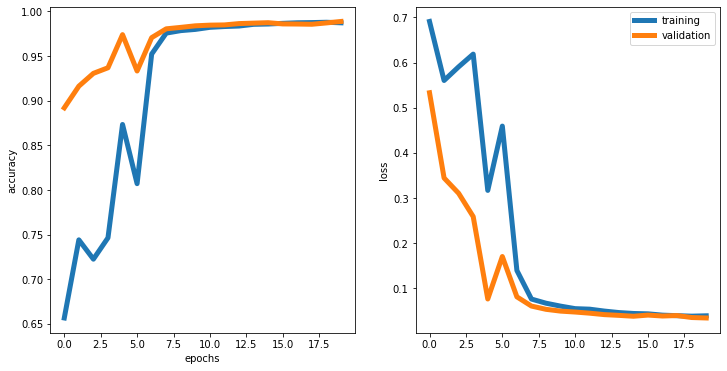

In [24]:
fig, axs = plt.subplots(nrows = 1, ncols =2 , figsize = (12,6))
axs[0].plot(range(len(vgg16_model.history.history['accuracy'])), vgg16_model.history.history['accuracy'], linewidth = 5, label = "training")
axs[0].plot(range(len(vgg16_model.history.history['accuracy'])), vgg16_model.history.history['val_accuracy'], linewidth = 5, label = "validation")
axs[1].plot(range(len(vgg16_model.history.history['loss'])), vgg16_model.history.history['loss'], linewidth = 5, label = "training")
axs[1].plot(range(len(vgg16_model.history.history['loss'])), vgg16_model.history.history['val_loss'], linewidth = 5, label = "validation")
axs[0].set_xlabel("epochs")
axs[0].set_xlabel("epochs")
axs[0].set_ylabel("accuracy")
axs[1].set_ylabel("loss")
plt.legend()

In [25]:
vgg16_model.load_weights("/content/save_model/improved_vgg16_concrete_crack.h5")
loss, accuracy = vgg16_model.evaluate(test_dataloader, verbose=1)

16/16 [==============================] - 10s 595ms/step - loss: 0.0227 - accuracy: 0.9930


### 3.2 - Cassava Leaf Disease

#### Load data

In [13]:
!wget --no-check-certificate https://storage.googleapis.com/emcassavadata/cassavaleafdata.zip \
                -O /content/cassavaleafdata.zip
!unzip '/content/cassavaleafdata.zip'

Streaming output truncated to the last 5000 lines.
  inflating: cassavaleafdata/train/cgm/train-cgm-679.jpg  
  inflating: cassavaleafdata/train/cgm/train-cgm-68.jpg  
  inflating: cassavaleafdata/train/cgm/train-cgm-680.jpg  
  inflating: cassavaleafdata/train/cgm/train-cgm-681.jpg  
  inflating: cassavaleafdata/train/cgm/train-cgm-682.jpg  
  inflating: cassavaleafdata/train/cgm/train-cgm-683.jpg  
  inflating: cassavaleafdata/train/cgm/train-cgm-684.jpg  
  inflating: cassavaleafdata/train/cgm/train-cgm-685.jpg  
  inflating: cassavaleafdata/train/cgm/train-cgm-686.jpg  
  inflating: cassavaleafdata/train/cgm/train-cgm-687.jpg  
  inflating: cassavaleafdata/train/cgm/train-cgm-688.jpg  
  inflating: cassavaleafdata/train/cgm/train-cgm-689.jpg  
  inflating: cassavaleafdata/train/cgm/train-cgm-69.jpg  
  inflating: cassavaleafdata/train/cgm/train-cgm-690.jpg  
  inflating: cassavaleafdata/train/cgm/train-cgm-691.jpg  
  inflating: cassavaleafdata/train/cgm/train-cgm-692.jpg  
  infla

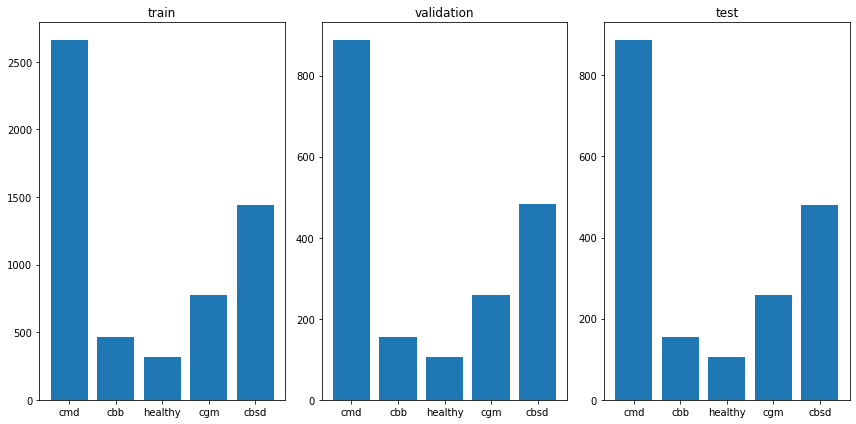

In [14]:
base_dir = '/content/cassavaleafdata'
train_dir = os.path.join(base_dir, 'train')
valid_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

labels_dict = {
     "cbb": "Cassava Bacterial Blight (CBB)",
     "cbsd": "Cassava Brown Streak Disease (CBSD)",
     "cgm": "Cassava Green Mottle (CGM)",
     "cmd": "Cassava Mosaic Disease (CMD)",
     "healthy": "Healthy"
}

def show_labels(data_dir):
    data = os.listdir(data_dir)
    fig, ax = plt.subplots(1, len(data), figsize=(12,6))
    for idx in range(len(data)):
        sub_dir = os.path.join(data_dir, data[idx])
        labels = os.listdir(sub_dir)
        list_data = []
        for label in labels:
            image_files = list(paths.list_images(os.path.join(sub_dir, label)))
            list_data.append(len(image_files))
        ax[idx].bar(labels, list_data)
        ax[idx].set_title(data[idx])
        # ax[idx].axis('off')
    plt.tight_layout()
    plt.show()
    
show_labels(base_dir)

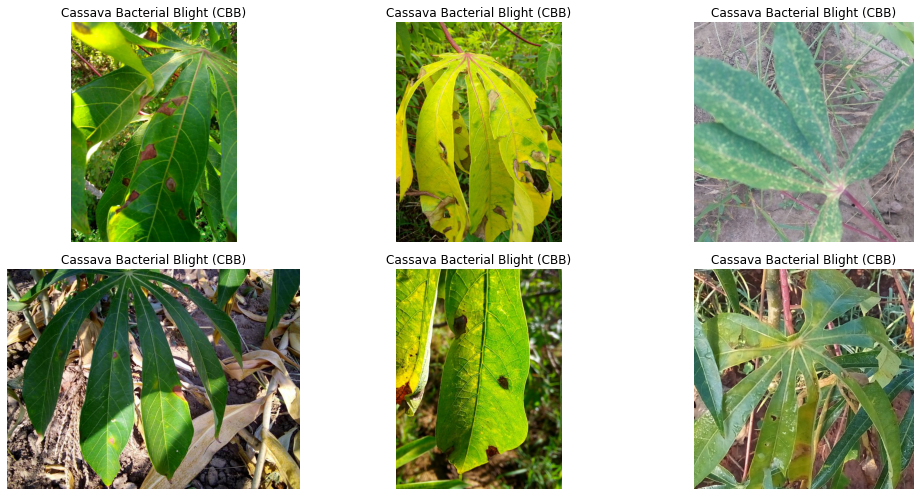

In [15]:
def plot_images(data_dir, label, num_sample=6):
    data_dir = os.path.join(data_dir, label)
    image_files = list(paths.list_images(data_dir))[:num_sample]
    fig, ax = plt.subplots(2,num_sample//2, figsize=(14,7))
    for i, image_dir in enumerate(image_files):
        img = mpimg.imread(image_dir)
        label = image_dir.split('/')[-2]
        ax[i//(num_sample//2)][i%(num_sample//2)].imshow(img)
        ax[i//(num_sample//2)][i%(num_sample//2)].set_title(labels_dict[label])
        ax[i//(num_sample//2)][i%(num_sample//2)].axis('off')
    plt.tight_layout()
    plt.show()

plot_images(train_dir, label="cbb")

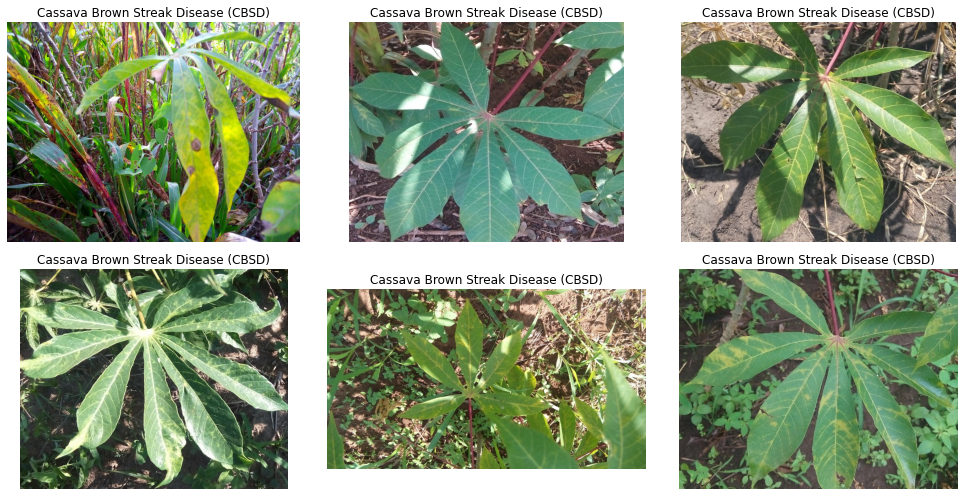

In [16]:
plot_images(train_dir, label="cbsd")

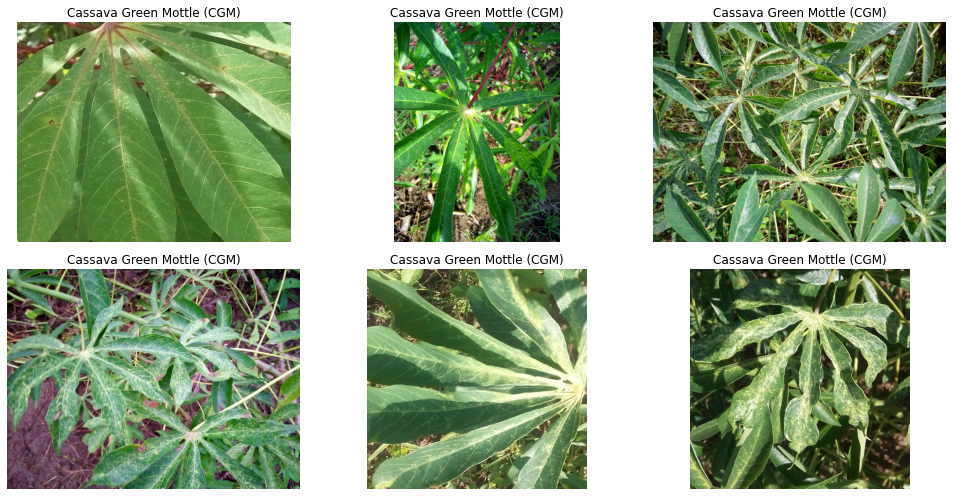

In [17]:
plot_images(train_dir, label="cgm")

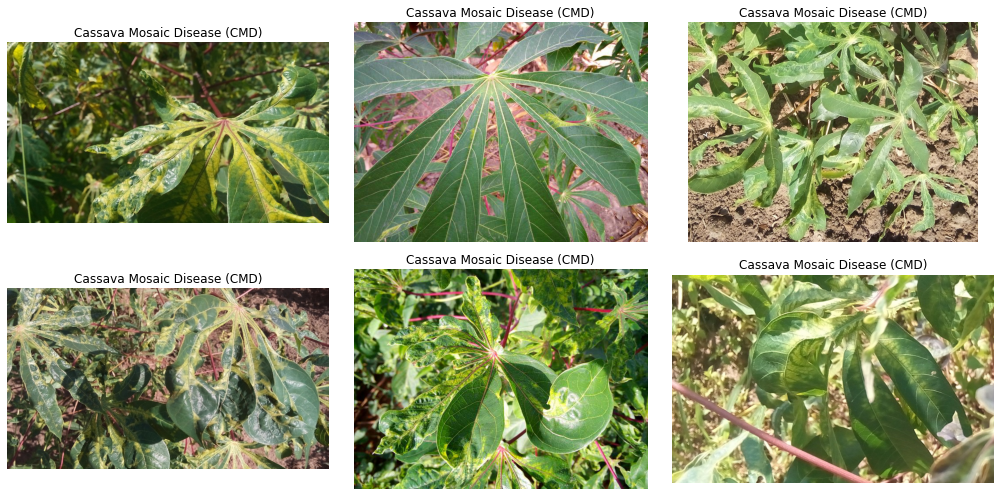

In [18]:
plot_images(train_dir, label="cmd")

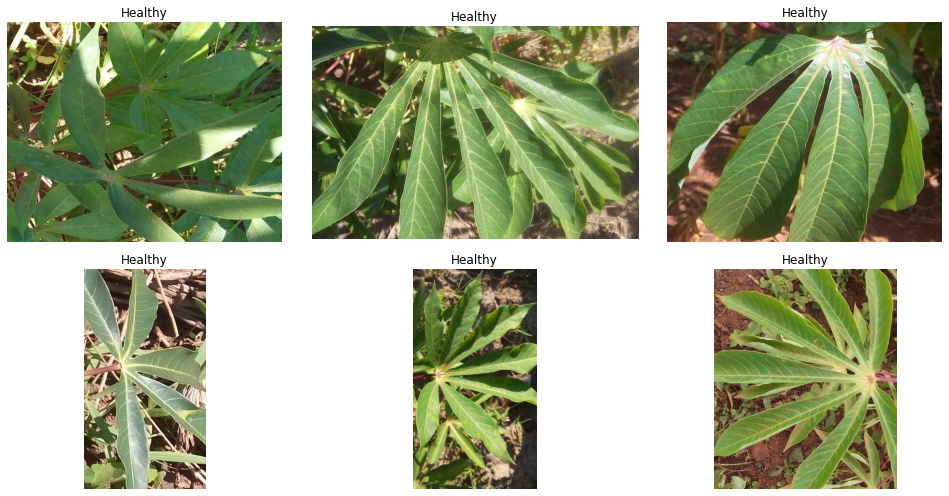

In [19]:
plot_images(train_dir, label="healthy")

#### Processing

Found 5656 images belonging to 5 classes.
Found 1889 images belonging to 5 classes.
Found 1885 images belonging to 5 classes.


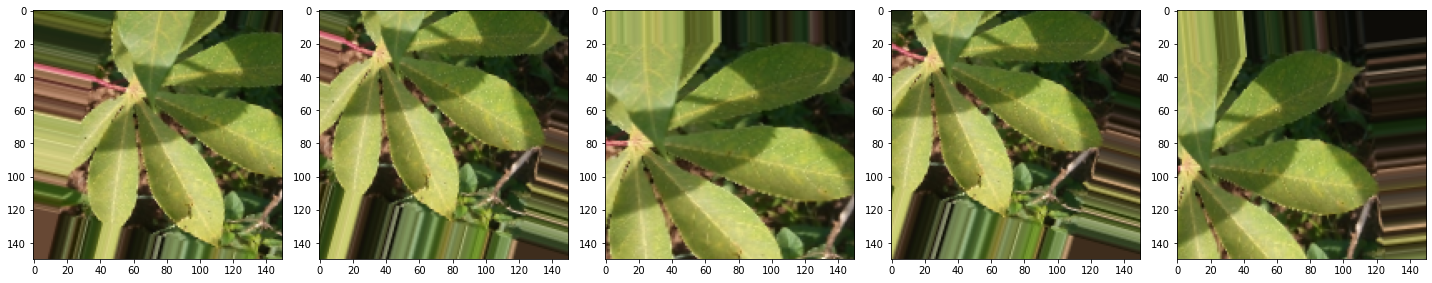

In [20]:
img_size = 150
output_size = 5
batch_size = 128

train_datagen = ImageDataGenerator( rescale=1.0/255.0,
                                    rotation_range=30, 
                                    zoom_range=0.15,
                                    width_shift_range=0.2,
                                    height_shift_range=0.2,
                                    shear_range=0.15,
                                    horizontal_flip=True,
                                    fill_mode="nearest" )

val_datagen = ImageDataGenerator(rescale=1.0/255.0)

test_datagen = ImageDataGenerator(rescale=1.0/255.0)

# prepare iterators
train_dataloader = train_datagen.flow_from_directory(train_dir, 
                                                     batch_size=batch_size, 
                                                     target_size=(img_size, img_size))

valid_dataloader = val_datagen.flow_from_directory(valid_dir,  
                                         batch_size=batch_size, 
                                         target_size=(img_size, img_size))

test_dataloader = test_datagen.flow_from_directory(test_dir, 
                                           batch_size=batch_size,
                                           shuffle = False,
                                           target_size=(img_size, img_size))

def show_aug(images):
    fig, axis = plt.subplots(1, 5, figsize=(20, 20))
    axis = axis.flatten()
    for img, ax in zip(images, axis):
        ax.imshow(img)
    plt.tight_layout()
    plt.show()

imgs = [train_dataloader[0][0][0] for i in range(5)]
show_aug(imgs)

#### Model LeNet

In [21]:
lenet_model = tf.keras.models.Sequential(
            tf.keras.layers.Conv2D(), # C1 #your code here
            tf.keras.layers.AvgPool2D(), # S2 #your code here
            tf.keras.layers.Conv2D(), # C3 #your code here
            tf.keras.layers.AvgPool2D(), # S4 #your code here
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(), # C5 #your code here
            tf.keras.layers.Dense(), # F6 #your code here
            tf.keras.layers.Dense()) # Output layer, #your code here

lenet_model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
lenet_model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_15 (Conv2D)          (None, 150, 150, 6)       456       
                                                                 
 average_pooling2d_2 (Averag  (None, 75, 75, 6)        0         
 ePooling2D)                                                     
                                                                 
 conv2d_16 (Conv2D)          (None, 71, 71, 16)        2416      
                                                                 
 average_pooling2d_3 (Averag  (None, 35, 35, 16)       0         
 ePooling2D)                                                     
                                                                 
 flatten_2 (Flatten)         (None, 19600)             0         
                                                                 
 dense_6 (Dense)             (None, 120)              

In [28]:
num_epochs = 10

checkpoint_path = "/content/save_model/lenet_cassava.h5"

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
            filepath=checkpoint_path,
            verbose=1,
            save_weights_only=True,
            monitor='val_accuracy',
            mode='max',
            save_best_only=True)

learning_rate_reduction = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', 
                                            patience = 2, 
                                            verbose=1,
                                            factor=0.5, 
                                            min_lr=0.00001)

history = lenet_model.fit(train_dataloader,
                                epochs = num_epochs,
                                validation_data = valid_dataloader,
                                callbacks=[model_checkpoint, learning_rate_reduction])

Epoch 1/10
45/45 [==============================] - ETA: 0s - loss: 1.2839 - accuracy: 0.4913
Epoch 1: val_accuracy improved from -inf to 0.55850, saving model to /content/save_model/lenet_cassava.h5
45/45 [==============================] - 72s 2s/step - loss: 1.2839 - accuracy: 0.4913 - val_loss: 1.2101 - val_accuracy: 0.5585 - lr: 0.0010
Epoch 2/10
45/45 [==============================] - ETA: 0s - loss: 1.2292 - accuracy: 0.5382
Epoch 2: val_accuracy improved from 0.55850 to 0.57226, saving model to /content/save_model/lenet_cassava.h5
45/45 [==============================] - 71s 2s/step - loss: 1.2292 - accuracy: 0.5382 - val_loss: 1.1826 - val_accuracy: 0.5723 - lr: 0.0010
Epoch 3/10
45/45 [==============================] - ETA: 0s - loss: 1.1997 - accuracy: 0.5530
Epoch 3: val_accuracy improved from 0.57226 to 0.59873, saving model to /content/save_model/lenet_cassava.h5
45/45 [==============================] - 71s 2s/step - loss: 1.1997 - accuracy: 0.5530 - val_loss: 1.1292 - va

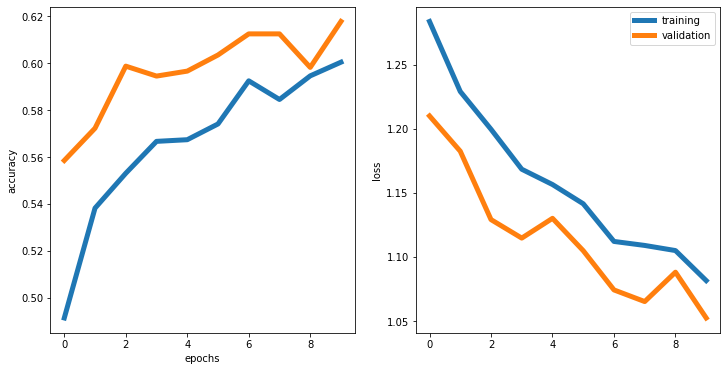

In [29]:
fig, axs = plt.subplots(nrows = 1, ncols =2 , figsize = (12,6))
axs[0].plot(range(len(lenet_model.history.history['accuracy'])), lenet_model.history.history['accuracy'], linewidth = 5, label = "training")
axs[0].plot(range(len(lenet_model.history.history['accuracy'])), lenet_model.history.history['val_accuracy'], linewidth = 5, label = "validation")
axs[1].plot(range(len(lenet_model.history.history['loss'])), lenet_model.history.history['loss'], linewidth = 5, label = "training")
axs[1].plot(range(len(lenet_model.history.history['loss'])), lenet_model.history.history['val_loss'], linewidth = 5, label = "validation")
axs[0].set_xlabel("epochs")
axs[0].set_xlabel("epochs")
axs[0].set_ylabel("accuracy")
axs[1].set_ylabel("loss")
plt.legend()

In [30]:
lenet_model.load_weights("/content/save_model/lenet_cassava.h5")
loss, accuracy = lenet_model.evaluate(test_dataloader, steps=len(test_dataloader), verbose=1)
test_pred = lenet_model.predict(test_dataloader)
confusion_matrix(test_pred.argmax(axis = 1), test_dataloader.labels)
report = classification_report(test_pred.argmax(axis = 1), 
                      test_dataloader.labels, 
                      labels = [0,1,2,3,4])
print(report)


15/15 [==============================] - 11s 766ms/step
              precision    recall  f1-score   support

           0       0.11      0.68      0.19        25
           1       0.70      0.57      0.63       588
           2       0.03      0.50      0.06        16
           3       0.93      0.66      0.77      1256
           4       0.00      0.00      0.00         0

    accuracy                           0.63      1885
   macro avg       0.35      0.48      0.33      1885
weighted avg       0.84      0.63      0.71      1885



/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


#### Model VGG-16

In [34]:
vgg16_model = tf.keras.models.Sequential(
                # 1st Conv Block
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.MaxPool2D(), #your code here

                # 2nd Conv Block
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.MaxPool2D(), #your code here

                # 3rd Conv block
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.MaxPool2D(), #your code here

                # 4th Conv block
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.MaxPool2D(), #your code here

                # 5th Conv block
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.Conv2D(), #your code here
                tf.keras.layers.MaxPool2D(), #your code here

                # Fully connected layers
                tf.keras.layers.Flatten(),
                tf.keras.layers.Dense(), #your code here
                tf.keras.layers.Dense(), #your code here
                tf.keras.layers.Dense() #your code here

vgg16_model.compile(optimizer='adam',loss="categorical_crossentropy", metrics=['accuracy'])
vgg16_model.summary()


Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_34 (Conv2D)          (None, 150, 150, 64)      1792      
                                                                 
 conv2d_35 (Conv2D)          (None, 150, 150, 64)      36928     
                                                                 
 max_pooling2d_11 (MaxPoolin  (None, 75, 75, 64)       0         
 g2D)                                                            
                                                                 
 conv2d_36 (Conv2D)          (None, 75, 75, 128)       73856     
                                                                 
 conv2d_37 (Conv2D)          (None, 75, 75, 128)       147584    
                                                                 
 max_pooling2d_12 (MaxPoolin  (None, 38, 38, 128)      0         
 g2D)                                                 

In [35]:
num_epochs=10
checkpoint_path = "/content/save_model/vgg16_cassava.h5"

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
            filepath=checkpoint_path,
            verbose=1,
            save_weights_only=True,
            monitor='val_accuracy',
            mode='max',
            save_best_only=True)

learning_rate_reduction = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', 
                                            patience = 2, 
                                            verbose=1,
                                            factor=0.5, 
                                            min_lr=0.00001)

history = vgg16_model.fit(train_dataloader,
                                epochs = num_epochs,
                                validation_data = valid_dataloader,
                                callbacks=[model_checkpoint, learning_rate_reduction])

Epoch 1/10
45/45 [==============================] - ETA: 0s - loss: 44.8625 - accuracy: 0.4188
Epoch 1: val_accuracy improved from -inf to 0.46956, saving model to /content/save_model/vgg16_cassava.h5
45/45 [==============================] - 136s 2s/step - loss: 44.8625 - accuracy: 0.4188 - val_loss: 1.3712 - val_accuracy: 0.4696 - lr: 0.0010
Epoch 2/10
45/45 [==============================] - ETA: 0s - loss: 1.3538 - accuracy: 0.4699
Epoch 2: val_accuracy did not improve from 0.46956
45/45 [==============================] - 83s 2s/step - loss: 1.3538 - accuracy: 0.4699 - val_loss: 1.3412 - val_accuracy: 0.4696 - lr: 0.0010
Epoch 3/10
45/45 [==============================] - ETA: 0s - loss: 1.3442 - accuracy: 0.4699
Epoch 3: val_accuracy did not improve from 0.46956

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
45/45 [==============================] - 83s 2s/step - loss: 1.3442 - accuracy: 0.4699 - val_loss: 1.3400 - val_accuracy: 0.4696 - lr: 0.0010
Epoc

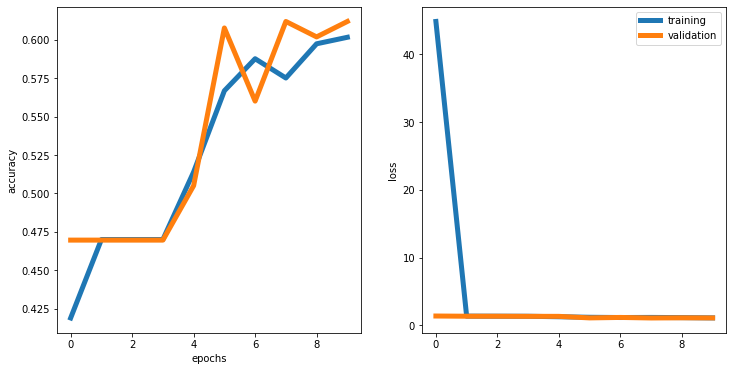

In [36]:
fig, axs = plt.subplots(nrows = 1, ncols =2 , figsize = (12,6))
axs[0].plot(range(len(vgg16_model.history.history['accuracy'])), vgg16_model.history.history['accuracy'], linewidth = 5, label = "training")
axs[0].plot(range(len(vgg16_model.history.history['accuracy'])), vgg16_model.history.history['val_accuracy'], linewidth = 5, label = "validation")
axs[1].plot(range(len(vgg16_model.history.history['loss'])), vgg16_model.history.history['loss'], linewidth = 5, label = "training")
axs[1].plot(range(len(vgg16_model.history.history['loss'])), vgg16_model.history.history['val_loss'], linewidth = 5, label = "validation")
axs[0].set_xlabel("epochs")
axs[0].set_xlabel("epochs")
axs[0].set_ylabel("accuracy")
axs[1].set_ylabel("loss")
plt.legend()

In [37]:
vgg16_model.load_weights("/content/save_model/vgg16_cassava.h5")
loss, accuracy = vgg16_model.evaluate(test_dataloader, steps=len(test_dataloader), verbose=1)
test_pred = vgg16_model.predict(test_dataloader)
confusion_matrix(test_pred.argmax(axis = 1), test_dataloader.labels)
report = classification_report(test_pred.argmax(axis = 1), 
                      test_dataloader.labels, 
                      labels = [0,1,2,3,4])
print(report)

15/15 [==============================] - 13s 848ms/step
              precision    recall  f1-score   support

           0       0.01      1.00      0.03         2
           1       0.64      0.55      0.59       556
           2       0.00      0.00      0.00         0
           3       0.93      0.62      0.75      1327
           4       0.00      0.00      0.00         0

    accuracy                           0.60      1885
   macro avg       0.32      0.43      0.27      1885
weighted avg       0.84      0.60      0.70      1885



/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


## Quiz

### Exercise 1

### Exercise 3

### Exercise 4 & 5

### Exercise 6-7-8